In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
from matplotlib_venn import venn3
import matplotlib.pyplot as plt


from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm


This file contains the code to merge the different filters into one single file and converted to boolean for easier access to whether a gene is present.

Venn diagram is set up to compare any 3 filters. downset plot could not be set down because of dataframe incompatibility

## Loading Datas

In [2]:
pre_filter_path = Path("/project/imoskowitz/yubin/1-sc_practice/Differential_Gene_Analysis/DataFrames/Pre-pseudobulk-filter")
post_filter_path = Path("/project/imoskowitz/yubin/1-sc_practice/Differential_Gene_Analysis/DataFrames/Post-pseudobulk-filter")
pre_filter_path = sorted(pre_filter_path.iterdir())
post_filter_path = sorted(post_filter_path.iterdir())
pre_filters = [] # list of pre filter DEG ranging from genes present in 0-5 cells filter
for file_path in pre_filter_path:
    if file_path.is_file():  
        pre_filters.append(pd.read_csv(file_path))

post_filters = [] # list of post filter DEG ranging from genes present in 0-5 cells filter
for file_path in post_filter_path:
    if file_path.is_file():  
        post_filters.append(pd.read_csv(file_path))



## Displaying the number of genes present in those filters

In [3]:
[len(filter) for filter in pre_filters]

[33696, 26519, 24709, 23640, 22875]

In [4]:
[len(filter) for filter in post_filters]

[33696, 26519, 24456, 22989, 21810, 20516, 19004]

## Venn Diagrams All genes

### Drawing a three set venn diagram:
- the no filter, 2 cell count filter before pseudobulk, and 2 sample count filter after pseudobulk

In [103]:
# Sets of gene from all the filter Dataframes
pre_filter_sets = [set(pre_filters[i].iloc[:,1]) for i in range(len(pre_filters))]
post_filter_sets = [set(post_filters[i].iloc[:,1]) for i in range(len(post_filters))]


In [102]:
pre_filters[0].iloc[:,1]

0                      Xkr4
1                    Gm1992
2                   Gm19938
3                   Gm37381
4                       Rp1
                ...        
33691    ENSMUSG00000095523
33692    ENSMUSG00000095475
33693    ENSMUSG00000094855
33694    ENSMUSG00000095019
33695    ENSMUSG00000095041
Name: Unnamed: 0, Length: 33696, dtype: object

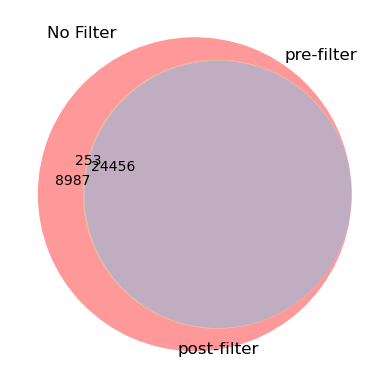

In [104]:
# No filter vs 2 pre vs 2 post
venn3((pre_filter_sets[0], pre_filter_sets[2], post_filter_sets[2]), ('No Filter', 'pre-filter', 'post-filter'))
plt.show()

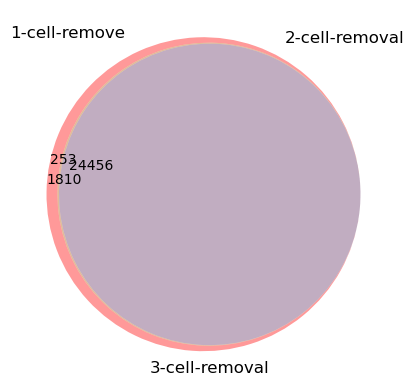

In [105]:

# pre 1 vs 2 vs 3
venn3((pre_filter_sets[1], pre_filter_sets[2], post_filter_sets[2]), ('1-cell-remove', '2-cell-removal', '3-cell-removal'),)
plt.show()

## Up regulated genes comparison

In [ ]:
# First we have to create a subset of downregulated genes for all filters
pre_filters[0].loc[:,"diff_expr"].unique()

array(['NS', 'down', 'up'], dtype=object)



Each filter has the column diff_expr, which contain "up". We can create a set of genes that is marked "up" for each 

In [24]:
np.array(pre_filters[0].loc[:,"diff_expr"] == "up")

array([False, False, False, ..., False, False, False])

In [ ]:
# We iterate through each index in the pre_filter list, take rows where diff_expr is "up", and convert it into a set
# The column is 1 because it contains the gene name
up_reg_pre_filter = [set(pre_filters[i].iloc[np.array(pre_filters[i].loc[:,"diff_expr"] == "up"),1]) for i in range(len(pre_filters))]
up_reg_post_filter = [set(post_filters[i].iloc[np.array(post_filters[i].loc[:,"diff_expr"] == "up"),1]) for i in range(len(post_filters))]

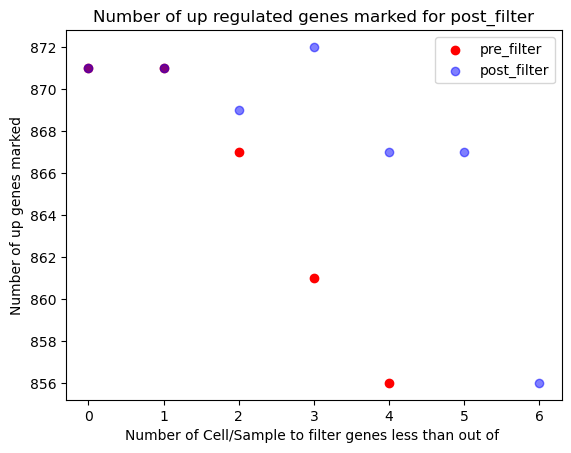

In [ ]:
figure, axs = plt.figure

plt.scatter(y = [len(up_reg_pre_filter[i]) for i in range(len(up_reg_pre_filter))], x = np.arange(len(up_reg_pre_filter)), color = "red", label = "pre_filter")
plt.title("Number of up regulated genes marked for pre_filter")
plt.xticks(np.arange(len(up_reg_pre_filter)))

plt.scatter(y = [len(up_reg_post_filter[i]) for i in range(len(up_reg_post_filter))], x = np.arange(len(up_reg_post_filter)), color = "blue", alpha = 0.5, label = "post_filter")
plt.title("Number of up regulated genes marked for post_filter")
plt.xticks(np.arange(len(up_reg_post_filter)))

# set Labels
plt.legend()
plt.ylabel('Number of up genes marked')
plt.xlabel("Number of Cell/Sample to filter genes less than out of ")
plt.show()

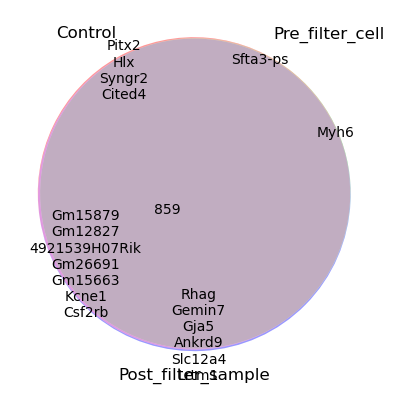

In [ ]:
# Now we have the set, we can pass into venn3 for comparison

set1, set2, set3 = up_reg_post_filter[0], up_reg_pre_filter[3], up_reg_post_filter[3]
Control_Pre_Post = (set1, set2, set3)

abc = set1 & set2 & set3  # Center intersection, not very useful
ab_ = (set1 & set2) - set3 # 1&2 only
a_c = (set1 & set3) - set2 # 1&3 only
_bc = (set2 & set3) - set1 # 2&3 only
a__ = set1 - set2 - set3
_b_ = set2 - set1 - set3
__c = set3 - set2 - set1

plt.Figure(figsize=(12,8))
v = venn3(Control_Pre_Post, ("Control", "Pre_filter_cell", "Post_filter_sample"))
v.get_label_by_id('110').set_text("\n".join(ab_))
v.get_label_by_id('101').set_text('\n'.join(a_c))
v.get_label_by_id('011').set_text('\n'.join(_bc))
v.get_label_by_id('100').set_text('\n'.join(a__))
v.get_label_by_id('010').set_text('\n'.join(_b_))
v.get_label_by_id('001').set_text('\n'.join(__c))



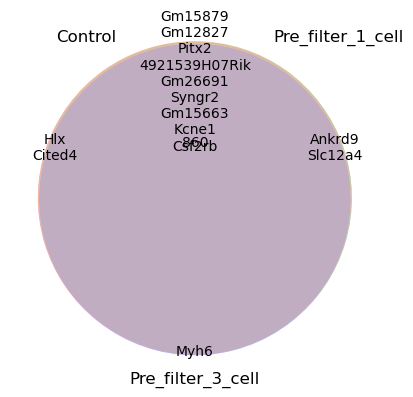

In [ ]:
set1, set2, set3 = up_reg_post_filter[0], up_reg_pre_filter[1], up_reg_pre_filter[3]
Control_Pre_Pre = (set1, set2, set3)




plt.Figure(figsize=(12,8))
v = venn3(Control_Pre_Pre, ("Control", "Pre_filter_1_cell", "Pre_filter_3_cell"))

# Labeling
abc = set1 & set2 & set3  # Center intersection, not very useful
ab_ = (set1 & set2) - set3 # 1&2 only
a_c = (set1 & set3) - set2 # 1&3 only
_bc = (set2 & set3) - set1 # 2&3 only
a__ = set1 - set2 - set3
_b_ = set2 - set1 - set3
__c = set3 - set2 - set1
v.get_label_by_id('110').set_text("\n".join(ab_))
v.get_label_by_id('101').set_text('\n'.join(a_c))
v.get_label_by_id('011').set_text('\n'.join(_bc))
v.get_label_by_id('100').set_text('\n'.join(a__))
v.get_label_by_id('010').set_text('\n'.join(_b_))
v.get_label_by_id('001').set_text('\n'.join(__c))

Post filter removed Pitx2 !!!


## Down Regulated genes Comparison

In [163]:
down_reg_pre_filter = [set(pre_filters[i].iloc[np.array(pre_filters[i].loc[:,"diff_expr"] == "down"),1]) for i in range(len(pre_filters))]
down_reg_post_filter = [set(post_filters[i].iloc[np.array(post_filters[i].loc[:,"diff_expr"] == "down"),1]) for i in range(len(post_filters))]

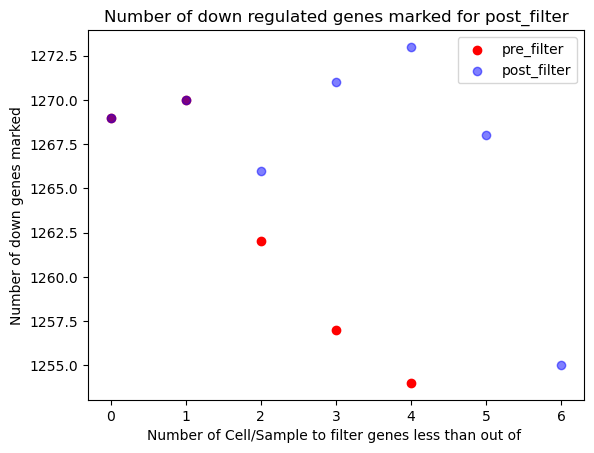

In [164]:
plt.scatter(y = [len(down_reg_pre_filter[i]) for i in range(len(down_reg_pre_filter))], x = np.arange(len(down_reg_pre_filter)), color = "red", label = "pre_filter")
plt.title("Number of down regulated genes marked for pre_filter")
plt.xticks(np.arange(len(down_reg_pre_filter)))

plt.scatter(y = [len(down_reg_post_filter[i]) for i in range(len(down_reg_post_filter))], x = np.arange(len(down_reg_post_filter)), color = "blue", alpha = 0.5, label = "post_filter")
plt.title("Number of down regulated genes marked for post_filter")
plt.xticks(np.arange(len(down_reg_post_filter)))

# set Labels
plt.legend()
plt.ylabel('Number of down genes marked')
plt.xlabel("Number of Cell/Sample to filter genes less than out of ")
plt.show()

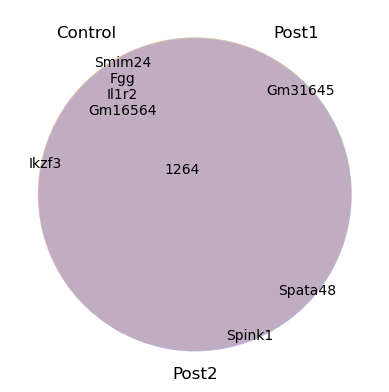

In [ ]:
set1, set2, set3 = down_reg_pre_filter[0], down_reg_post_filter[1], down_reg_post_filter[2]
plt.Figure(figsize=(12,8))
v = venn3((set1, set2, set3), ("Control", "Post1", "Post2"))


# Labeling
abc = set1 & set2 & set3  # Center intersection, not very useful
ab_ = (set1 & set2) - set3 # 1&2 only
a_c = (set1 & set3) - set2 # 1&3 only
_bc = (set2 & set3) - set1 # 2&3 only
a__ = set1 - set2 - set3
_b_ = set2 - set1 - set3
__c = set3 - set2 - set1
v.get_label_by_id('110').set_text("\n".join(ab_))
# v.get_label_by_id('101').set_text('\n'.join(a_c))
v.get_label_by_id('011').set_text('\n'.join(_bc))
v.get_label_by_id('100').set_text('\n'.join(a__))
v.get_label_by_id('010').set_text('\n'.join(_b_))
v.get_label_by_id('001').set_text('\n'.join(__c))

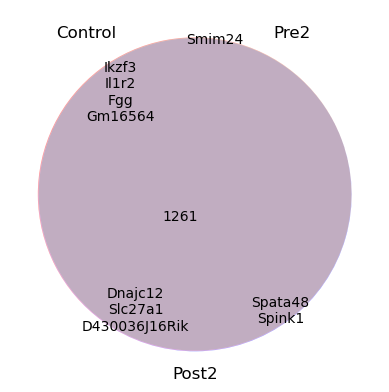

In [ ]:
set1, set2, set3 = down_reg_pre_filter[0], down_reg_pre_filter[2], down_reg_post_filter[2]

v = venn3((set1, set2, set3), ("Control", "Pre2", "Post2"))

# Labeling
abc = set1 & set2 & set3  # Center intersection, not very useful
ab_ = (set1 & set2) - set3 # 1&2 only
a_c = (set1 & set3) - set2 # 1&3 only
_bc = (set2 & set3) - set1 # 2&3 only
a__ = set1 - set2 - set3
_b_ = set2 - set1 - set3
__c = set3 - set2 - set1
v.get_label_by_id('110').set_text("\n".join(ab_))
v.get_label_by_id('101').set_text('\n'.join(a_c))
#v.get_label_by_id('011').set_text('\n'.join(_bc))
v.get_label_by_id('100').set_text('\n'.join(a__))
#v.get_label_by_id('010').set_text('\n'.join(_b_))
v.get_label_by_id('001').set_text('\n'.join(__c))

# TODO: Make a function for labeling, and have this function check for empty set before labeling

## Comparing up and down regulated, should should not have any overlaps

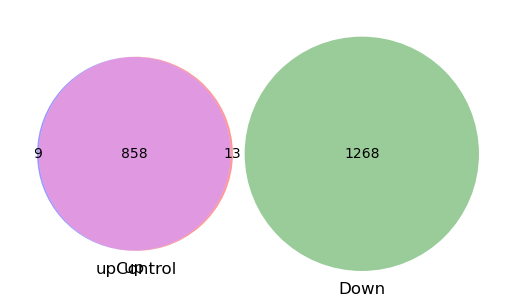

In [189]:
set1, set2, set3 = up_reg_pre_filter[0], down_reg_post_filter[5], up_reg_post_filter[4]
plt.Figure(figsize=(12,8))
v = venn3((set1, set2, set3), ("upControl", "Down", "up"))


# Labeling
abc = set1 & set2 & set3  # Center intersection, not very useful
ab_ = (set1 & set2) - set3 # 1&2 only
a_c = (set1 & set3) - set2 # 1&3 only
_bc = (set2 & set3) - set1 # 2&3 only
a__ = set1 - set2 - set3
_b_ = set2 - set1 - set3
__c = set3 - set2 - set1
#v.get_label_by_id('110').set_text("\n".join(ab_))
# v.get_label_by_id('101').set_text('\n'.join(a_c))
#v.get_label_by_id('011').set_text('\n'.join(_bc))
#v.get_label_by_id('100').set_text('\n'.join(a__))
#v.get_label_by_id('010').set_text('\n'.join(_b_))
#v.get_label_by_id('001').set_text('\n'.join(__c))

TODO: ma plot, adding Batch effect contrast and comparing pca and deg number.


